K-Nearest Neighbors (KNN) Classification


K = 1
Accuracy: 0.71


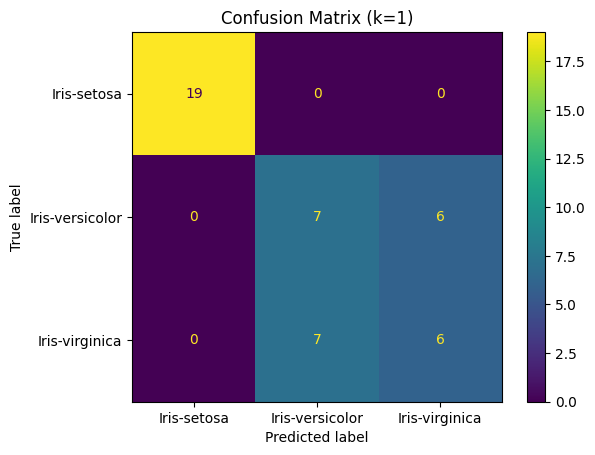

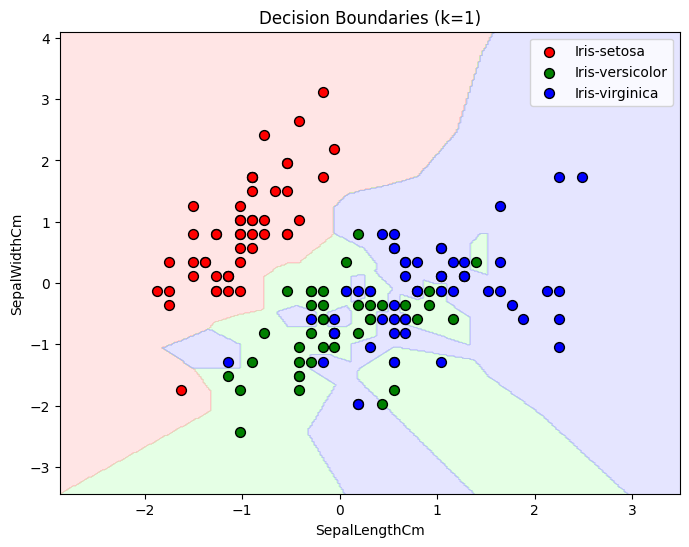


K = 3
Accuracy: 0.80


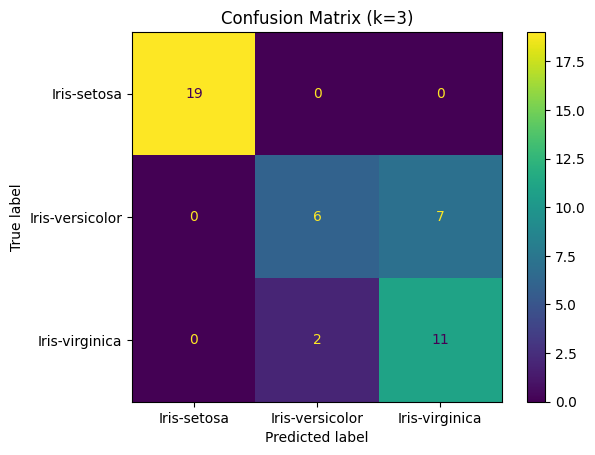

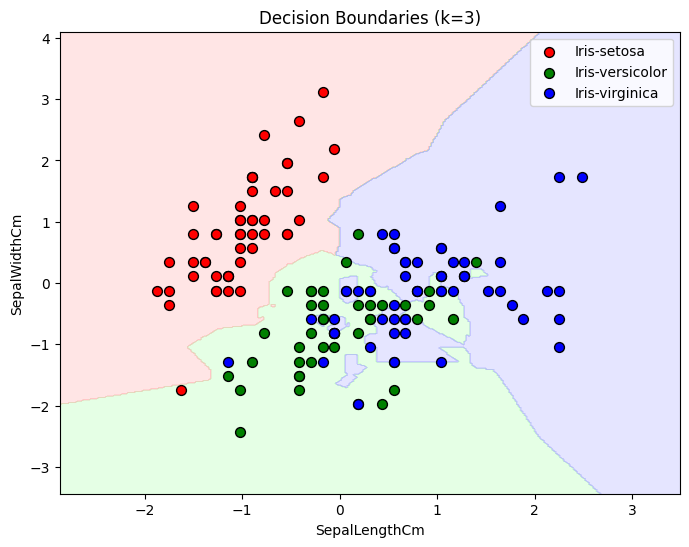


K = 5
Accuracy: 0.80


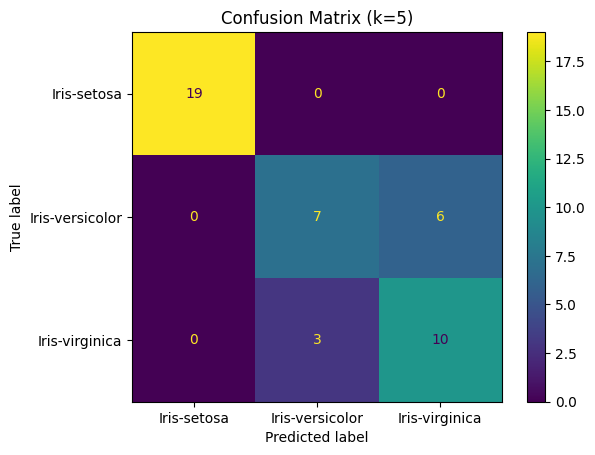

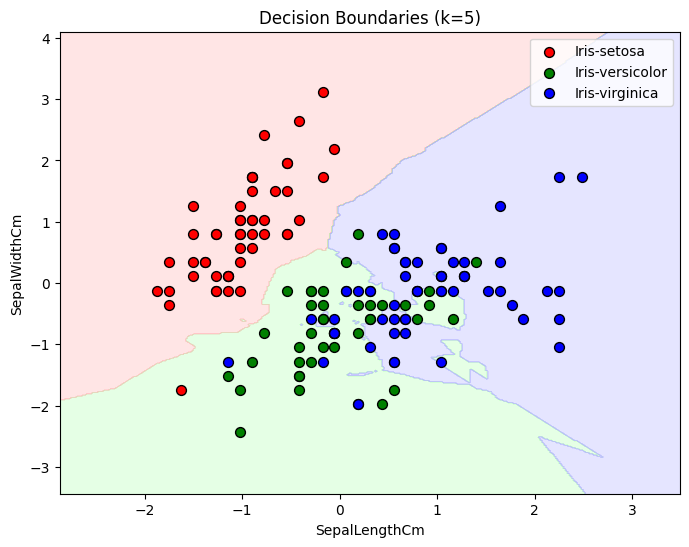


K = 7
Accuracy: 0.80


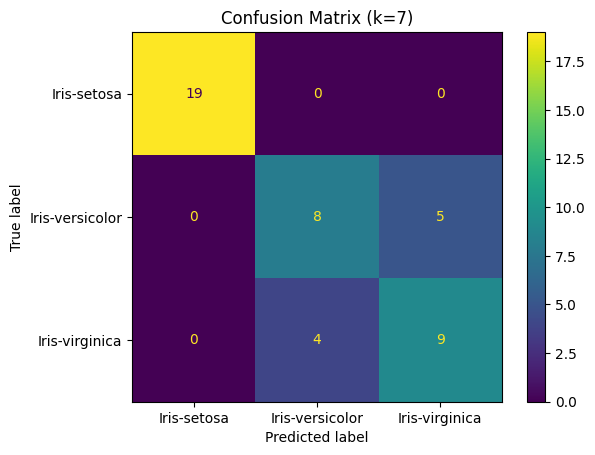

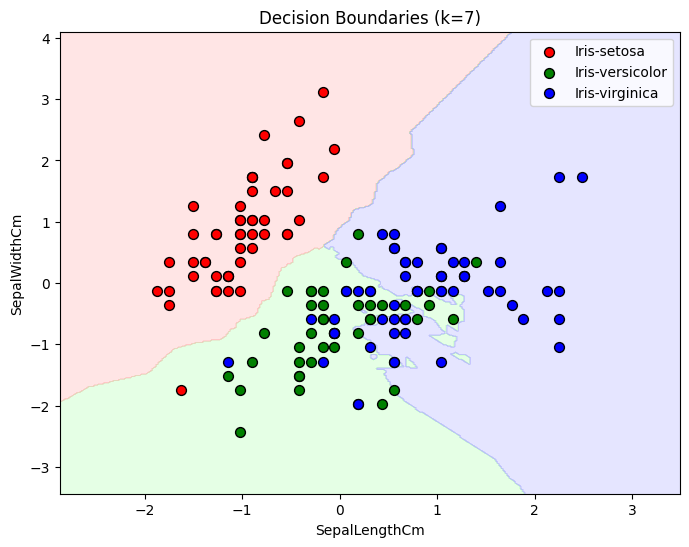


K = 9
Accuracy: 0.82


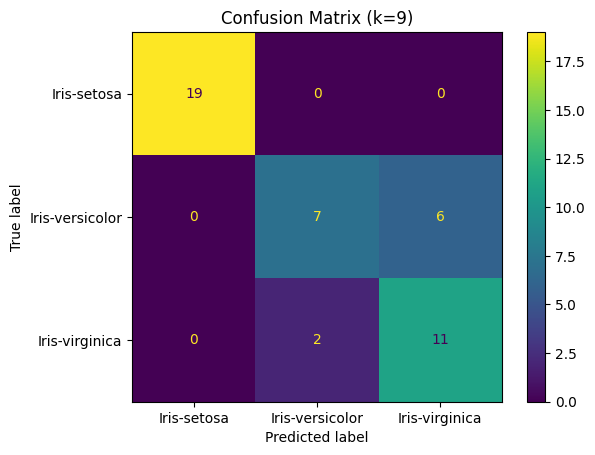

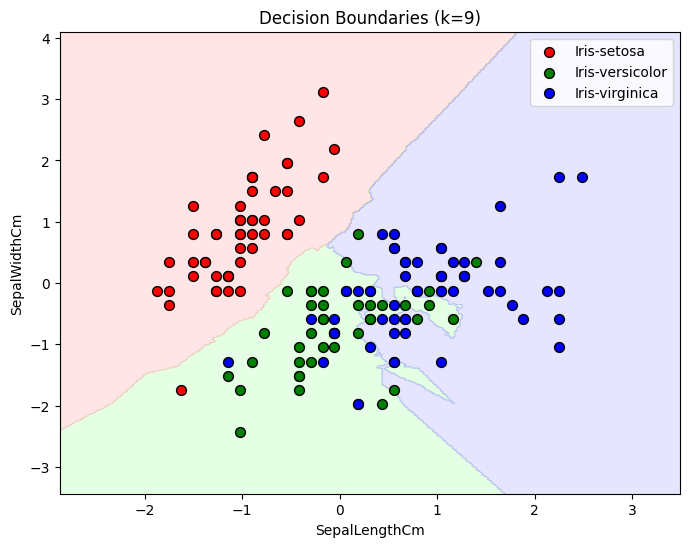

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

df = pd.read_csv('/content/Iris.csv')

# Drop ID column if it exists
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

# Features and target
X = df.iloc[:, :-1]  # All columns except the last one (Species)
y = df.iloc[:, -1]   # Species column

# Use only two features for visualization
X_vis = X.iloc[:, :2]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# Encode class labels
y_encoded = pd.factorize(y)[0]
class_names = y.unique()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    for i, color in zip(np.unique(y), cmap_bold):
        plt.scatter(X[y == i, 0], X[y == i, 1], c=color, label=class_names[i], edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel(X_vis.columns[0])
    plt.ylabel(X_vis.columns[1])
    plt.legend()
    plt.show()

# Train and evaluate for different K values
for k in [1, 3, 5, 7, 9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nK = {k}")
    print(f"Accuracy: {acc:.2f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot()
    plt.title(f"Confusion Matrix (k={k})")
    plt.show()

    plot_decision_boundaries(X_scaled, y_encoded, model, f"Decision Boundaries (k={k})")
